### This notebook compute "VSS4. Human Development Index" indicator for the 27 basins of IKI Project

Spanish: Índice de Desarrollo Humano

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  

**Project #:** 0219481  

**Last modified:** 9 Jan 2026  

**Status:** Complete and loaded in SQLite database.  

**QA Status:** reviewed by Scott Sheeder  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad  
 
**Inputs:**   Shapefile of COMIDs and districts, Indice de Desarrollo Humano (IDH) 2019 de Programa de las Naciones Unidas para el Desarrollo (PNUD, 2019): https://www.undp.org/es/peru/publicaciones/el-reto-de-la-igualdad

**Outputs:** 
 
**Assumptions:** Assume ID based on majority district associated with each COMID. 
 
**Future work:**  Could look into using a proportional method as opposed to a majority district method. Could look into calculating the IDH from scratch for each COMID but this would require further data. 
 
**Notes:** 

In [ ]:
## Steps for QC
# Verify that the first code cells follow this structure
# 1) import libraries
# 2) set up user and database path (this will eventually change based on how we set up the repo/distribute the input data)
# 3) set up indicator ID and get scenarios from the database - for now we are just populating the database for scenarios 1 and 2, but there should be commented lines to get all available scenarios from the database
# 4) define filepaths for input data (again this will eventually change so for now we want all the filepaths in one block to change later)

# Then verify that the rest of the code performs the intended calculations and outputs the expected results. You can run up until the sql insert which is the last three cells in the notebook.
# Make sure the code to perform the calculations is well-organized and commented for clarity.
# Add notes about the methodology, assumptions, and anything that sticks out about the results in the markdown block at the top of the page.
# Add any notes about NaN/0 handling in the markdown block under notes or assumptions
# Add a section in the markdown "QA performed by:" so that we know who checked and when 

In [1]:
import pandas as pd
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'nreynolds'
#user = 'sbakar'
#user = 'ssheeder'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 404 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [5]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

# inDH = fr'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/VSS4_IDH-2019.xlsx'
inDH = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad\VSS4_IDH-2019.xlsx"

In [6]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
InDH= pd.read_excel(inDH, sheet_name= 'Distrital')

In [7]:
#FORMATTING THE DATAFRAME

#make the second row the header
InDH.columns = InDH.iloc[1]
InDH = InDH[2:].reset_index(drop=True)

#remove empty rows N
InDH = InDH.dropna(axis=0, how='all')  # Drop rows that are completely NaN
#remove empty columns
InDH = InDH.dropna(axis=1, how='all')  # Drop columns that are completely NaN

#keep UBIGEO and Índice de Desarrollo Humano columns only
InDH = InDH[['UBIGEO', 'Índice de Desarrollo Humano']].copy()

#Rename UBIGEO to District_ID for merging
InDH = InDH.rename(columns={'UBIGEO': 'District_ID'})

#Remove any rows where the value is not a number 
InDH = InDH[pd.to_numeric(InDH['Índice de Desarrollo Humano'], errors='coerce').notnull()]

In [8]:
#MERGE DATAFRAMES BASED ON MAJORITY DISTRICT ID PER COMID

# Convert both columns to strings to be able to join them together
subbasins_gdf['IDDIST'] = subbasins_gdf['IDDIST'].astype(str)
InDH['District_ID'] = InDH['District_ID'].astype(str)

#Rename Índice de Desarrollo Humano column to IDH
InDH = InDH.rename(columns={'Índice de Desarrollo Humano': 'IDH'})

#Round to 2 decimal places 
InDH['IDH'] = InDH['IDH'].astype(float).round(2)

#merge Total_Dist column back to subbasins_gdf based on IDDIST and District_ID
subbasins_gdf = subbasins_gdf.merge(InDH[['District_ID', 'IDH']], left_on='IDDIST', right_on='District_ID', how='left')

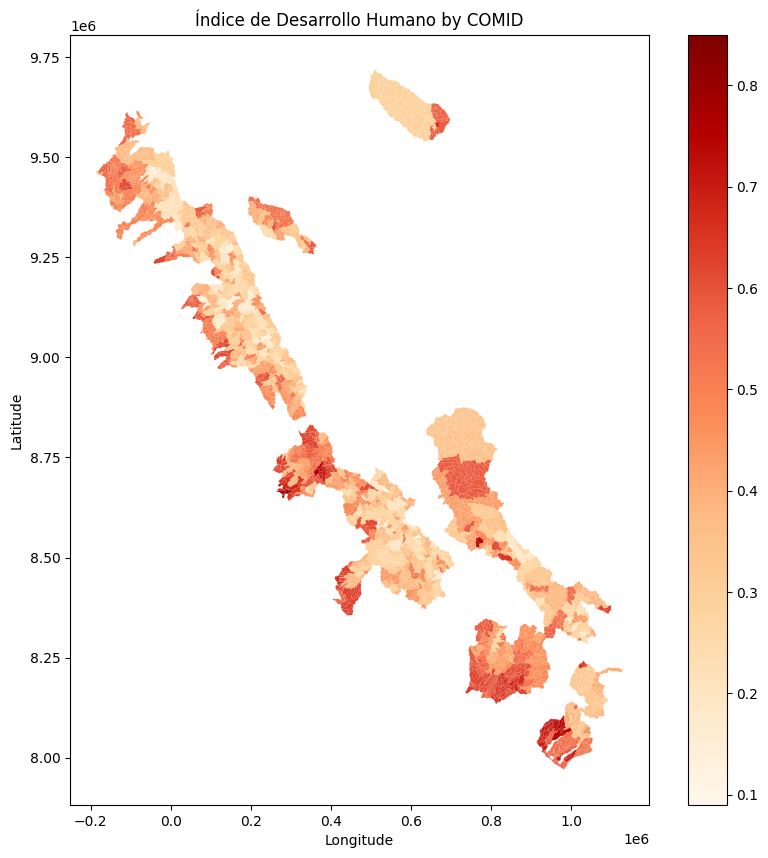

In [9]:
#PLOT THE RESULTS

subbasins_gdf.plot(column='IDH', cmap='OrRd', legend=True, figsize=(10, 10))
plt.title('Índice de Desarrollo Humano by COMID')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

SQLITE INSERT 

In [10]:
# insert results into the database 
insert_data= subbasins_gdf 
value_column= 'IDH' 

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

#use unique scenario IDs
scenario_ids_unique = sorted(set(scenario_ids))

for scn_id in scenario_ids_unique:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [12]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['IDH']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 404  Min: 0, Max: 1

=== Values to be inserted (by scenario) ===
   index      IDH
0    min     0.09
1    max     0.85
2  count  3526.00
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [13]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()